# Capstone 2025: YOLO vs SSD for real time object detection. Data Processing

## Data Pre-Processing

In [ ]:
# Necessary libraries for data pre-processing
import os
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import cv2
import random
from pathlib import Path
import numpy as np
import tqdm
import albumentations as A
from collections import defaultdict
from tqdm import tqdm
tqdm.pandas()  # Enable tqdm for Pandas
import shutil
import time
from matplotlib import patches
from collections import Counter
from collections import deque
from google.colab import drive


In [2]:
!python --version

Python 3.11.12


In [1]:
# Mount Google Drive
drive.mount('/content/drive')

NameError: name 'drive' is not defined

In [ ]:
#Working directory set up
"""
PROJECT_DIR = Path().resolve()
DATA_DIR = PROJECT_DIR / "datasets" / "Agroverse"
IMAGE_DIR = DATA_DIR / "Argoverse-1.1" / "images" #Manually changed changed folder name containing the image folders from "tracking" to "images"
ANNOTATION_DIR = DATA_DIR / "Argoverse-HD" / "annotations"
LABEL_DIR = DATA_DIR / "Argoverse-1.1" / "labels"  #These are Normalized YOLO format annotations made with the code provided by Acrolytics. See the YOLO training notebook
"""

# Define base directory inside Google Drive
PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Team 8 Capstone")
DATA_DIR = PROJECT_DIR / "datasets" / "Agroverse"
IMAGE_DIR = DATA_DIR / "Argoverse-1.1" / "images"
ANNOTATION_DIR = DATA_DIR / "Argoverse-HD" / "annotations"
LABEL_DIR = DATA_DIR / "Argoverse-1.1" / "labels"
print(f"Project Directory: {PROJECT_DIR}")
print(f"Image Directory: {IMAGE_DIR}")
print(f"Annotation Directory: {ANNOTATION_DIR}")
print(f"Label Directory: {LABEL_DIR}")

Project Directory: /content/drive/MyDrive/Colab Notebooks/Team 8 Capstone
Image Directory: /content/drive/MyDrive/Colab Notebooks/Team 8 Capstone/datasets/Agroverse/Argoverse-1.1/images
Annotation Directory: /content/drive/MyDrive/Colab Notebooks/Team 8 Capstone/datasets/Agroverse/Argoverse-HD/annotations
Label Directory: /content/drive/MyDrive/Colab Notebooks/Team 8 Capstone/datasets/Agroverse/Argoverse-1.1/labels


#### Exploring the annotations files

In [ ]:
# Load train.json
with open(ANNOTATION_DIR / "train.json", "r") as f:
    train_data = json.load(f)
# Check available keys
print("Keys in train.json:", train_data.keys())

# Display first few items
if "annotations" in train_data:
    print("Sample annotations:", train_data["annotations"][:3])
else:
    print("No annotations found in train.json")


Keys in train.json: dict_keys(['categories', 'images', 'annotations', 'sequences', 'seq_dirs', 'coco_subset', 'coco_mapping', 'n_tracks'])
Sample annotations: [{'id': 0, 'image_id': 0, 'bbox': [898, 584, 251, 228], 'category_id': 2, 'area': 57228.0, 'iscrowd': False, 'ignore': False, 'track': 0}, {'id': 1, 'image_id': 0, 'bbox': [459, 425, 408, 362], 'category_id': 5, 'area': 147696.0, 'iscrowd': False, 'ignore': False, 'track': 1}, {'id': 2, 'image_id': 0, 'bbox': [416, 272, 27, 72], 'category_id': 6, 'area': 1944.0, 'iscrowd': False, 'ignore': False, 'track': 2}]


In [ ]:
#Printing class/category names from the train.json file
# Extract category mappings
class_name_mapping = {cat["id"]: cat["name"] for cat in train_data["categories"]}

# Print  class names
print("Extracted Class Names from JSON:")
print(class_name_mapping)


Extracted Class Names from JSON:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'bus', 5: 'truck', 6: 'traffic_light', 7: 'stop_sign'}


In [ ]:
# Making a dictionary of the class for future use
CLASS_NAMES = {
    0: "person",
    1: "bicycle",
    2: "car",
    3: "motorcycle",
    4: "bus",
    5: "truck",
    6: "traffic_light",
    7: "stop_sign"
}

In [ ]:
# Print first few seq_dirs
print("\nSample seq_dirs:")
for i in range(min(5, len(train_data["seq_dirs"]))):
    print(f"{i}: {train_data['seq_dirs'][i]}")

# Print sample sequences

print("\nSample sequences:")
print(train_data["sequences"][:3])

# Print coco_subset and coco_mapping

print("\nCOCO Subset Info:")
print(train_data["coco_subset"])

print("\nCOCO Mapping Info:")
print(train_data["coco_mapping"])

# Print total number of tracks

print("\nTotal number of tracks:", train_data["n_tracks"])


print("\nSample image names:")
for img in train_data["images"][:5]:
    print(f"ID: {img['id']}, Name: {img['name']}, SID: {img['sid']}")



Sample seq_dirs:
0: train/02cf0ce1-699a-373b-86c0-eb6fd5f4697a/ring_front_center
1: train/043aeba7-14e5-3cde-8a5c-639389b6d3a6/ring_front_center
2: train/08a8b7f0-c317-3bdb-b3dc-b7c9b6d033e2/ring_front_center
3: train/0ef28d5c-ae34-370b-99e7-6709e1c4b929/ring_front_center
4: train/10b3a1d8-e56c-38be-aaf7-ef2f862a5c4e/ring_front_center

Sample sequences:
['02cf0ce1-699a-373b-86c0-eb6fd5f4697a', '043aeba7-14e5-3cde-8a5c-639389b6d3a6', '08a8b7f0-c317-3bdb-b3dc-b7c9b6d033e2']

COCO Subset Info:
[0, 1, 2, 3, 5, 7, 9, 11]

COCO Mapping Info:
[0, 1, 2, 3, 80, 4, 80, 5, 80, 6, 80, 7, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]

Total number of tracks: [38, 63, 86, 85, 99, 59, 79, 35, 58, 101, 37, 71, 78, 55, 70, 84, 64, 41, 95, 56, 60, 48, 57, 83, 141, 43, 85, 129, 64,

In [ ]:
#Checking the validation set annotations
# Define the path for the validation annotations
val_annotation_path = ANNOTATION_DIR / "val.json"

# Load the JSON file
with open(val_annotation_path, "r") as f:
    val_data = json.load(f)

# Check available keys
print("Keys in val.json:", val_data.keys())

# Display first few annotation items
if "annotations" in val_data:
    print("Sample annotations:", val_data["annotations"][:3])
else:
    print("No annotations found in val.json")

Keys in val.json: dict_keys(['categories', 'images', 'annotations', 'sequences', 'seq_dirs', 'coco_subset', 'coco_mapping', 'n_tracks'])
Sample annotations: [{'id': 0, 'image_id': 0, 'bbox': [935, 585, 131, 120], 'category_id': 2, 'area': 15720.0, 'iscrowd': False, 'ignore': False, 'track': 0}, {'id': 1, 'image_id': 0, 'bbox': [633, 467, 236, 259], 'category_id': 5, 'area': 61124.0, 'iscrowd': False, 'ignore': False, 'track': 1}, {'id': 2, 'image_id': 0, 'bbox': [867, 608, 29, 40], 'category_id': 2, 'area': 1160.0, 'iscrowd': False, 'ignore': False, 'track': 2}]


In [ ]:
#Checking the test annotations
# Define the path for the test annotations
test_annotation_path = ANNOTATION_DIR / "test-meta.json"

# Load the JSON
with open(test_annotation_path, "r") as f:
    test_data = json.load(f)

# Check available keys
print("Keys in test-meta.json:", test_data.keys())

# Display first few items
if "annotations" in test_data:
    print("Sample annotations:", test_data["annotations"][:3])
else:
    print("No annotations found in test-meta.json")

Keys in test-meta.json: dict_keys(['categories', 'images', 'sequences', 'seq_dirs', 'coco_subset', 'coco_mapping'])
No annotations found in test-meta.json


In [ ]:
# Calculate the average number of images per video for train, val, and test
def get_avg_images_per_video(image_dir):


    for split in ["train", "val", "test"]:
        split_path = image_dir / split
        video_folders = list(split_path.glob("*"))  # Get all video sequence folders

        print(f"{split.upper()} - {len(video_folders)} video sequences/videos found.")

        total_images = 0
        video_counts = 0

        for video_folder in video_folders:
            ring_front_center_path = video_folder / "ring_front_center"
            image_files = list(ring_front_center_path.glob("*.jpg"))  # Search for .jpg images

            if image_files:  # Folder empty?
                total_images += len(image_files)
                video_counts += 1

        # average images per video
        avg_images = total_images / video_counts if video_counts > 0 else 0
        print(f"Average number of images per video in {split}: {avg_images:.2f}\n")


get_avg_images_per_video(IMAGE_DIR)


TRAIN - 65 video sequences/videos found.
Average number of images per video in train: 605.91

VAL - 24 video sequences/videos found.
Average number of images per video in val: 627.58

TEST - 24 video sequences/videos found.
Average number of images per video in test: 521.12



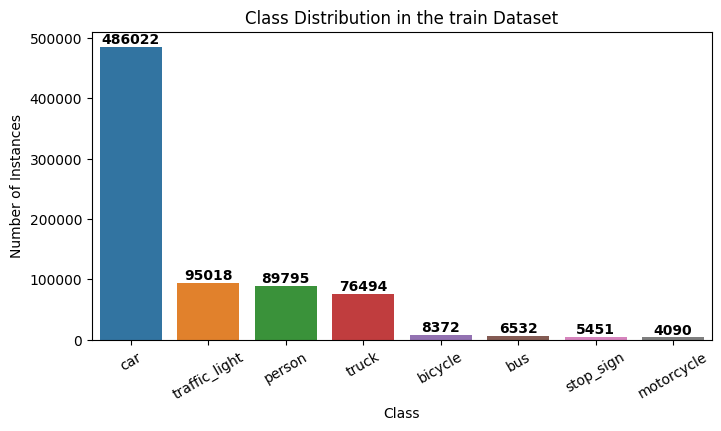

In [ ]:
# Read annotations and plot class distribution with class names
def plot_class_distribution(json_path, data_subset):

    # Loading annotation file
    with open(json_path, "r") as f:
        data = json.load(f)

    # Extract category IDs from annotations
    class_counts = {}
    for ann in data["annotations"]:
        class_id = ann["category_id"]
        class_counts[class_id] = class_counts.get(class_id, 0) + 1

    # Convert to DataFrame
    df_class = pd.DataFrame(list(class_counts.items()), columns=["Class ID", "Count"])

    # Replace class ID with class names
    df_class["Class Name"] = df_class["Class ID"].map(CLASS_NAMES)

    # Sort by count
    df_class = df_class.sort_values(by="Count", ascending=False)

    # Plot the class distribution
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x="Class Name", y="Count", hue="Class Name", data=df_class, legend=False)

    # Add exact count numbers on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Labels and title
    plt.xlabel("Class")
    plt.ylabel("Number of Instances")
    plt.title(f"Class Distribution in the {data_subset} Dataset")
    plt.xticks(rotation=30)
    plt.show()

# Plot train dataset
plot_class_distribution(ANNOTATION_DIR / "train.json", "train")

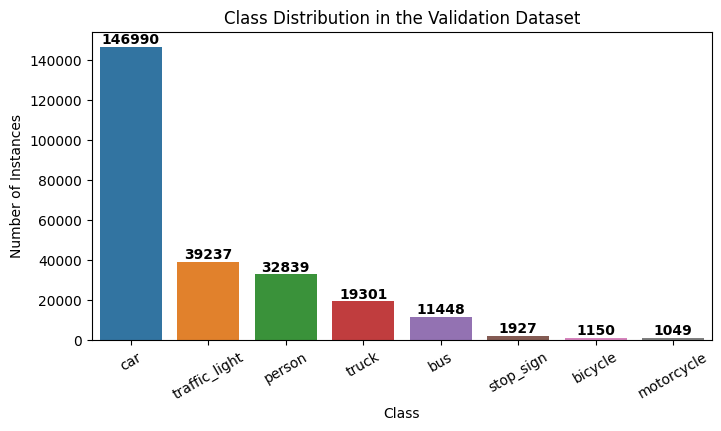

In [ ]:
plot_class_distribution(ANNOTATION_DIR / "val.json", "Validation")

### Visualizing some Images and their bounding boxes.

In [ ]:
# Load and visualize sample images with bounding boxes
def visualize_bbox(image_dir, annotations, image_info, num_samples=5):

    # Select first `num_samples` unique images
    unique_img_ids = list(set(ann["image_id"] for ann in annotations))
    sample_img_ids = random.sample(unique_img_ids, min(num_samples, len(unique_img_ids)))

    for img_id in sample_img_ids:
        # Extract video folder and image name
        video_folder_name = image_info[img_id]["video_folder"]
        image_name = image_info[img_id]["file_name"]

        # Construct the image path
        image_path = image_dir / "train" / video_folder_name / "ring_front_center" / image_name

        # Check if the image exists
        if not image_path.exists():
            print(f"Skipping missing image: {image_path}")
            continue

        # Load image
        img = cv2.imread(str(image_path))
        if img is None:
            print(f"Failed to load image: {image_path}")
            continue

        # Convert BGR to RGB for Matplotlib expects RGB format
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Filter all bounding boxes for this image
        image_annotations = [ann for ann in annotations if ann["image_id"] == img_id]

        for ann in image_annotations:
            bbox = ann["bbox"]
            category_id = ann["category_id"]
            class_name = CLASS_NAMES.get(category_id, "Unknown")

            # Draw bounding box
            x_min, y_min, width, height = map(int, bbox)
            x_max, y_max = x_min + width, y_min + height
            cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
            cv2.putText(img, class_name, (x_min, y_min - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Display image
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


In [ ]:
#Using train.json to visualize images with bounding boxes in the first 3 folders of the training set

# Extract "seq_dirs" (mapping "sid" to correct folder path)
seq_dirs = train_data["seq_dirs"]  # This is a list with folder names where index = sid

# Extract first 3 folder names from `train/`
train_path = IMAGE_DIR / "train"
selected_folders = sorted([f.name for f in train_path.iterdir() if f.is_dir()])[:3]

print(f"\nUsing the first 3 video folders: {selected_folders}")

# Fixing folder mapping to get correct path because it was repeating folder names.
sid_to_folder = {i: seq_dirs[i].replace("train/", "").replace("/ring_front_center", "") for i in range(len(seq_dirs))}

# Build "image_info" dictionary
image_info = {
    img["id"]: {
        "file_name": img["name"],
        "video_folder": sid_to_folder[img["sid"]],
    }
    for img in train_data["images"]
    if img["sid"] in sid_to_folder
}

# Extract images from selected folders
img_ids = [img["id"] for img in train_data["images"] if image_info[img["id"]]["video_folder"] in selected_folders]

# Extract annotations for selected images
annotations = [ann for ann in train_data["annotations"] if ann["image_id"] in img_ids]

print(f"\nTotal images available for visualization: {len(img_ids)}")
print(f"Total annotations available: {len(annotations)}")

# See random images with bounding boxes
visualize_bbox(IMAGE_DIR, annotations, image_info, num_samples=6)

Output hidden; open in https://colab.research.google.com to view.

### Finding duplicates from the train.json file

In [ ]:
# Convert annotations DataFrame
df_annotations = pd.DataFrame(train_data["annotations"])

# Convert 'bbox' (list) to a tuple
df_annotations["bbox"] = df_annotations["bbox"].apply(tuple)

# Find duplicate annotations
duplicate_annotations = df_annotations[df_annotations.duplicated(subset=["image_id", "category_id", "bbox"], keep=False)]

print(f"Total duplicate annotations found: {len(duplicate_annotations)}")

# Display first few duplicate rows
if not duplicate_annotations.empty:
    print("\nSample Duplicates:")
    print(duplicate_annotations.head(10))


Total duplicate annotations found: 2

Sample Duplicates:
            id  image_id              bbox  category_id    area  iscrowd  \
639931  639931     33177  (0, 586, 68, 42)            2  2856.0    False   
639932  639932     33177  (0, 586, 68, 42)            2  2856.0    False   

        ignore  track  
639931   False     68  
639932   False     69  


In [ ]:
# Remove duplicate annotations from train.json and save the file
df_annotations_cleaned = df_annotations.drop_duplicates(subset=["image_id", "category_id", "bbox"], keep="first")

# Copy full train.json structure
cleaned_train_data = train_data.copy()  # to make sure the original file is unchanged

# Update only the annotations section
cleaned_train_data["annotations"] = df_annotations_cleaned.to_dict(orient="records")

# Save cleaned dataset
cleaned_json_path = ANNOTATION_DIR / "no_dups_train.json"
with open(cleaned_json_path, "w") as f:
    json.dump(cleaned_train_data, f, indent=4)

print(f"Cleaned train dataset saved at {cleaned_json_path}")


Cleaned train dataset saved at /content/drive/MyDrive/Colab Notebooks/Team 8 Capstone/datasets/Agroverse/Argoverse-HD/annotations/no_dups_train.json


### Finding and removing duplicates in the val subset

In [ ]:
# Load val.json
val_json_path = ANNOTATION_DIR / "val.json"
with open(val_json_path, "r") as f:
    val_data = json.load(f)

# annotations DataFrame
df_val_annotations = pd.DataFrame(val_data["annotations"])

# Convert 'bbox' (list) to a tuple so it can be used for duplicate checking
df_val_annotations["bbox"] = df_val_annotations["bbox"].apply(tuple)

# Find duplicate annotations
duplicate_annotations = df_val_annotations[df_val_annotations.duplicated(subset=["image_id", "category_id", "bbox"], keep=False)]

# Print total duplicates
print(f"Total duplicate annotations found in val.json: {len(duplicate_annotations)}")

# Display first few duplicate rows
if not duplicate_annotations.empty:
    print("\nSample Duplicates in Validation Set:")
    print(duplicate_annotations.head(10))

Total duplicate annotations found in val.json: 2

Sample Duplicates in Validation Set:
          id  image_id                bbox  category_id   area  iscrowd  \
31786  31786      2152  (713, 615, 16, 43)            0  688.0    False   
31809  31809      2152  (713, 615, 16, 43)            0  688.0    False   

       ignore  track  
31786   False     57  
31809   False     83  


In [ ]:
# Remove duplicate annotations (keep only the first one
df_val_annotations_cleaned = df_val_annotations.drop_duplicates(subset=["image_id", "category_id", "bbox"], keep="first")

# Convert 'bbox' back to list (to maintain JSON format)
df_val_annotations_cleaned = df_val_annotations_cleaned.copy()
df_val_annotations_cleaned.loc[:, "bbox"] = df_val_annotations_cleaned["bbox"].apply(list)

# Preserve all other sections
cleaned_val_data = val_data.copy()  # Copy everything
cleaned_val_data["annotations"] = df_val_annotations_cleaned.to_dict(orient="records")  # Update only annotations

# Save cleaned dataset as no_dups_val.json
cleaned_val_json_path = ANNOTATION_DIR / "no_dups_val.json"
with open(cleaned_val_json_path, "w") as f:
    json.dump(cleaned_val_data, f, indent=4)

print(f"Cleaned validation dataset saved at {cleaned_val_json_path}")

Cleaned validation dataset saved at /content/drive/MyDrive/Colab Notebooks/Team 8 Capstone/datasets/Agroverse/Argoverse-HD/annotations/no_dups_val.json


### Data Augmentation and  Balancing

In [ ]:
#copying all de data into the new folder into colab to augment
#after augmentation data will be saved back into google drive

!cp -r "/content/drive/MyDrive/Colab Notebooks/Team 8 Capstone/datasets/Agroverse/"* /content/datasets/balanced_Agroverse/




In [ ]:
print("Copy Complete")

Copy Complete


In [ ]:
#New working directory definitions for augmentation. THE ENTIRE DATASET WAS COPIED TO BE EDITED. the opriginal dataset was not changed.
#see paths below for the new working directory
# IMPORTANT changed the name of the no_dups_train.json to original_train.json
"""
PROJECT_DIR = Path().resolve()
DATA_DIR = PROJECT_DIR / "datasets"
BALANCED_DIR = DATA_DIR / "balanced_Agroverse"
IMAGE_DIR = BALANCED_DIR / "Argoverse-1.1" / "images"
BALANCED_ANNOTATION_DIR = BALANCED_DIR / "Argoverse-HD" / "annotations"
original_train_anotation = BALANCED_ANNOTATION_DIR / "original_train.json" #changed the name of the no_dups_train.json to original_train.json
balanced_train_annotation_path = BALANCED_ANNOTATION_DIR / "balanced_train.json" #New file to be created with the balanced dataset
"""
#Paths For google drive using google colab
PROJECT_DIR = Path("/content")
DATA_DIR = PROJECT_DIR / "datasets"
BALANCED_DIR = DATA_DIR / "balanced_Agroverse"
IMAGE_DIR = BALANCED_DIR / "Argoverse-1.1" / "images"
BALANCED_ANNOTATION_DIR = BALANCED_DIR / "Argoverse-HD" / "annotations"

# Annotation files
original_train_anotation = BALANCED_ANNOTATION_DIR / "original_train.json"
balanced_train_annotation_path = BALANCED_ANNOTATION_DIR / "balanced_train.json"

In [ ]:
#changed the name of the no_dups_train.json to original_train.json
# Define paths
old_json = BALANCED_ANNOTATION_DIR / "no_dups_train.json"
new_json = BALANCED_ANNOTATION_DIR / "original_train.json"

# Rename the file
if old_json.exists():
    old_json.rename(new_json)
    print(f"Renamed to: {new_json.name}")
else:
    print("Old JSON file not found.")

Renamed to: original_train.json


#### Horizontal Flipping

In [ ]:
annotation_path = BALANCED_ANNOTATION_DIR / "original_train.json"
output_path = BALANCED_ANNOTATION_DIR / "balanced_train.json"

# Load original JSON
with open(annotation_path, "r") as f:
    train_data = json.load(f)

# Underrepresented classes
UNDERREPRESENTED_CLASSES = {1, 3, 4, 7} # bicycle, motorcycle, bus, stop_sign

# Build annotation lookup
annotation_lookup = defaultdict(list)
for ann in train_data["annotations"]:
    annotation_lookup[ann["image_id"]].append(ann)

# Map sid to folder
seq_dirs = train_data["seq_dirs"]
sid_to_folder = {
    i: seq_dirs[i].replace("train/", "").replace("/ring_front_center", "") for i in range(len(seq_dirs))
}

# Build image info dict
image_info = {
    img["id"]: {
        "file_name": img["name"],
        "video_folder": sid_to_folder[img["sid"]],
        "sid": img["sid"],
        "fid": img["fid"],
        "width": img["width"],
        "height": img["height"]
    }
    for img in train_data["images"]
    if img["sid"] in sid_to_folder
}

# Sort by underrepresented class counts
image_underrep_count = {
    img_id: sum(1 for ann in annotation_lookup[img_id] if ann["category_id"] in UNDERREPRESENTED_CLASSES)
    for img_id in image_info
}
sorted_images = sorted(image_underrep_count.keys(), key=lambda x: image_underrep_count[x], reverse=True)
top_25_percent = int(len(sorted_images) * 0.25)
selected_images = sorted_images[:top_25_percent]

# Define flipping function
def flip_image_and_bboxes(image, bboxes, img_width):
    flipped_image = cv2.flip(image, 1)
    flipped_bboxes = []
    for bbox in bboxes:
        x_min, y_min, width, height = bbox["bbox"]
        new_x_min = img_width - (x_min + width)
        flipped_bboxes.append({
            "bbox": [new_x_min, y_min, width, height],
            "category_id": bbox["category_id"]
        })
    return flipped_image, flipped_bboxes

# Counters
image_id_counter = max(img["id"] for img in train_data["images"]) + 1
annotation_id_counter = max(ann["id"] for ann in train_data["annotations"]) + 1

# Flip and update
for image_id in selected_images:
    img_data = image_info[image_id]
    bboxes = annotation_lookup[image_id]

    image_path = IMAGE_DIR / "train" / img_data["video_folder"] / "ring_front_center" / img_data["file_name"]
    if not image_path.exists():
        continue

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    flipped_image, flipped_bboxes = flip_image_and_bboxes(image, bboxes, img_data["width"])

    # Save flipped image
    new_file_name = f"{img_data['file_name'].split('.')[0]}_flipped.jpg"
    new_image_path = IMAGE_DIR / "train" / img_data["video_folder"] / "ring_front_center" / new_file_name
    new_image_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(new_image_path), cv2.cvtColor(flipped_image, cv2.COLOR_RGB2BGR))

    # Create image entry with full structure
    new_image_info = {
        "id": image_id_counter,
        "sid": img_data["sid"],
        "fid": img_data["fid"],
        "name": new_file_name,
        "width": img_data["width"],
        "height": img_data["height"]
    }
    train_data["images"].append(new_image_info)

    # Create flipped annotations
    for flipped_bbox in flipped_bboxes:
        new_ann = {
            "id": annotation_id_counter,
            "image_id": image_id_counter,
            "category_id": flipped_bbox["category_id"],
            "bbox": flipped_bbox["bbox"],
            "area": flipped_bbox["bbox"][2] * flipped_bbox["bbox"][3],
            "iscrowd": False,
            "ignore": False,
            "track": -1
        }
        train_data["annotations"].append(new_ann)
        annotation_id_counter += 1

    image_id_counter += 1

# Save updated JSON
with open(output_path, "w") as f:
    json.dump(train_data, f, indent=4)

print("Flipping complete. `balanced_train.json` updated with correct image structure.")


Flipping complete. `balanced_train.json` updated with correct image structure.


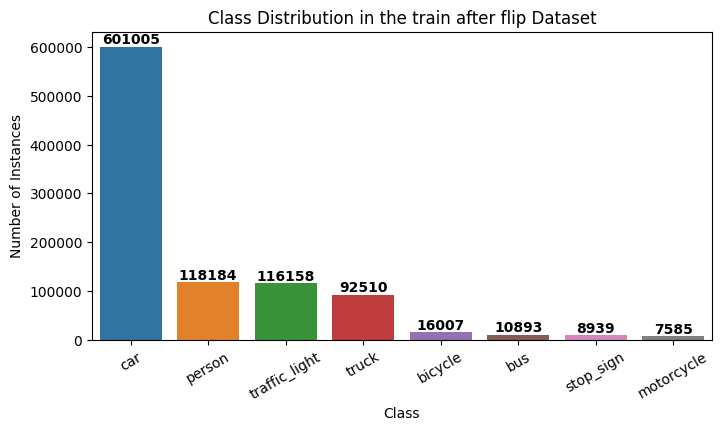

In [ ]:
plot_class_distribution(BALANCED_ANNOTATION_DIR / "balanced_train.json", "train after flip") #balanced dataset

In [ ]:
#Function to display the flipped image next to its original.
def visualize_flipped_image_pair(annotation_path, image_dir):
    # Load dataset
    with open(annotation_path, "r") as f:
        data = json.load(f)

    # Build sid-to-folder mapping
    sid_to_folder = {
        i: seq.replace("train/", "").replace("/ring_front_center", "")
        for i, seq in enumerate(data["seq_dirs"])
    }

    # Build image metadata lookup
    image_info = {
        img["id"]: {
            "name": img.get("file_name", img.get("name", "")),
            "sid": img.get("sid", -1)
        }
        for img in data["images"]
    }

    # Find a flipped image
    flipped_img = next(
        (img for img in data["images"] if "_flipped" in img.get("name", "")),
        None
    )
    if not flipped_img:
        print("No flipped images found.")
        return

    flipped_name = flipped_img["name"]
    base_base_name = flipped_name.split("_flipped")[0]  # e.g. "000123"

    # Find a matching original image (with same base name but not flipped)
    original_img_data = next(
        (img for img in data["images"]
         if img.get("name", "").startswith(base_base_name)
         and "_flipped" not in img.get("name", "")),
        None
    )

    if not original_img_data:
        print(f"No non-flipped version found for base name: {base_base_name}")
        return

    original_name = original_img_data["name"]
    folder = sid_to_folder.get(flipped_img.get("sid", -1), "unknown")

    # Build full paths
    original_path = image_dir / "train" / folder / "ring_front_center" / original_name
    flipped_path = image_dir / "train" / folder / "ring_front_center" / flipped_name

    # Load images
    original_img = cv2.imread(str(original_path))
    flipped_img_data = cv2.imread(str(flipped_path))
    if original_img is None or flipped_img_data is None:
        print("Could not load one of the images.")
        return

    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    flipped_img_data = cv2.cvtColor(flipped_img_data, cv2.COLOR_BGR2RGB)

    # Get bounding boxes
    def get_bboxes(img_name):
        img_id = next((k for k, v in image_info.items() if v["name"] == img_name), None)
        return [ann for ann in data["annotations"] if ann["image_id"] == img_id]

    original_bboxes = get_bboxes(original_name)
    flipped_bboxes = get_bboxes(flipped_name)

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    def draw_boxes(ax, img, bboxes, title):
        ax.imshow(img)
        for bbox in bboxes:
            x, y, w, h = bbox["bbox"]
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 5, f"{bbox['category_id']}", color='white',
                    fontsize=9, bbox=dict(facecolor='red', alpha=0.5))
        ax.set_title(title)
        ax.axis("off")

    draw_boxes(axes[0], original_img, original_bboxes, "Original Image")
    draw_boxes(axes[1], flipped_img_data, flipped_bboxes, "Flipped Image")
    plt.tight_layout()
    plt.show()

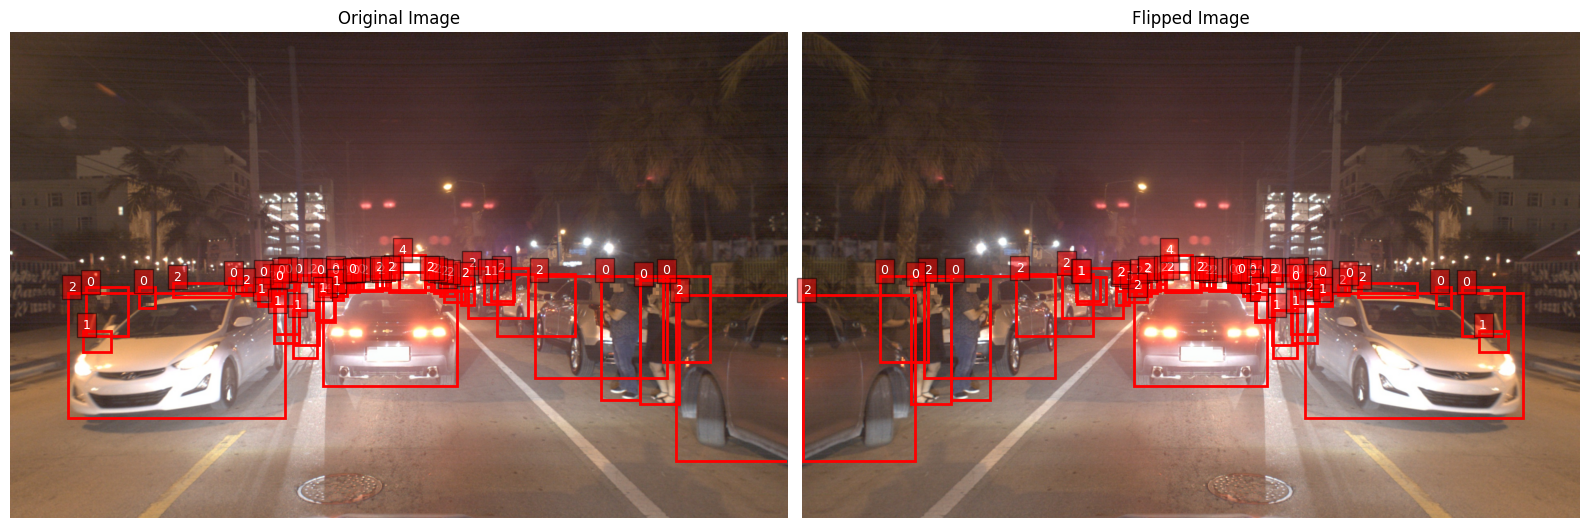

In [ ]:
annotation_path = BALANCED_ANNOTATION_DIR / "balanced_train.json"
visualize_flipped_image_pair(annotation_path, IMAGE_DIR)

#### Deleting images with just cars

In [ ]:
annotation_path = BALANCED_ANNOTATION_DIR / "balanced_train.json" #Note its the new JSON file
with open(annotation_path, "r") as f:
    data = json.load(f)

# Class definitions
OVERREPRESENTED_CLASS = 2  # Car

# Build annotation metadata
annotation_lookup = defaultdict(list)
class_counts_per_image = defaultdict(lambda: defaultdict(int))

for ann in data["annotations"]:
    annotation_lookup[ann["image_id"]].append(ann)
    class_counts_per_image[ann["image_id"]][ann["category_id"]] += 1

# Get image IDs to delete (car-only)
images_to_delete = {
    img_id for img_id, class_counts in class_counts_per_image.items()
    if len(class_counts) == 1 and OVERREPRESENTED_CLASS in class_counts
}

# Map sid to folder
seq_dirs = data["seq_dirs"]
sid_to_folder = {
    i: seq_dirs[i].replace("train/", "").replace("/ring_front_center", "") for i in range(len(seq_dirs))
}

# Collect file paths
image_paths_to_delete = []
image_id_to_path = {}

for img in data["images"]:
    if img["id"] in images_to_delete:
        folder = sid_to_folder[img["sid"]]
        path = IMAGE_DIR / "train" / folder / "ring_front_center" / img["name"]
        image_paths_to_delete.append(path)
        image_id_to_path[img["id"]] = path

print(f"{len(images_to_delete)} images are marked for deletion (car-only).")
print("Preview of 5 paths:")
for p in image_paths_to_delete[:5]:
    print("-", p)

465 images are marked for deletion (car-only).
Preview of 5 paths:
- /content/datasets/balanced_Agroverse/Argoverse-1.1/images/train/22160544-2216-2216-2216-722161741824/ring_front_center/ring_front_center_315966714125414208.jpg
- /content/datasets/balanced_Agroverse/Argoverse-1.1/images/train/22160544-2216-2216-2216-722161741824/ring_front_center/ring_front_center_315966714158714624.jpg
- /content/datasets/balanced_Agroverse/Argoverse-1.1/images/train/22160544-2216-2216-2216-722161741824/ring_front_center/ring_front_center_315966714192014936.jpg
- /content/datasets/balanced_Agroverse/Argoverse-1.1/images/train/22160544-2216-2216-2216-722161741824/ring_front_center/ring_front_center_315966714225315248.jpg
- /content/datasets/balanced_Agroverse/Argoverse-1.1/images/train/22160544-2216-2216-2216-722161741824/ring_front_center/ring_front_center_315966714258615664.jpg


In [ ]:
# Delete images and update JSON
remaining_images = [img for img in data["images"] if img["id"] not in images_to_delete]
remaining_annotations = [ann for ann in data["annotations"] if ann["image_id"] not in images_to_delete]

# Remove image files
deleted_count = 0
for path in image_paths_to_delete:
    if path.exists():
        path.unlink()
        deleted_count += 1

# Update JSON
data["images"] = remaining_images
data["annotations"] = remaining_annotations
# Save updated JSON
with open(annotation_path, "w") as f:
    json.dump(data, f, indent=4)

print(f"\n Deleted {deleted_count} image files and updated balanced_train.json.")


 Deleted 465 image files and updated balanced_train.json.


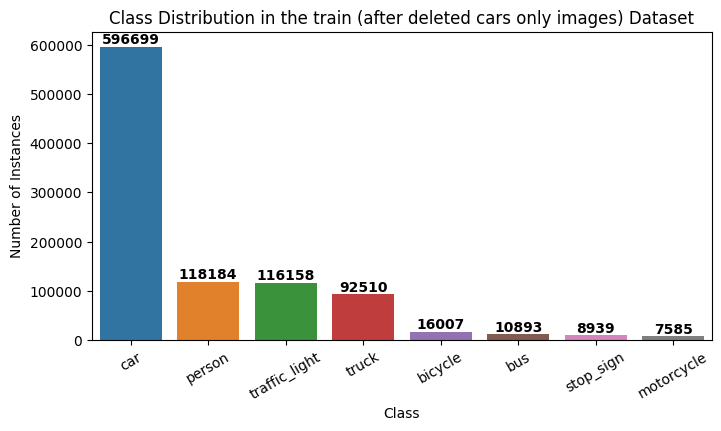

In [ ]:
plot_class_distribution(BALANCED_ANNOTATION_DIR / "balanced_train.json", "train (after deleted cars only images)") #balanced dataset

#### Copy Pasting Augmentation

In [ ]:

# Load balanced annotations
annotation_path = BALANCED_ANNOTATION_DIR / "balanced_train.json" #Note its the new JSON file

# Load JSON
with open(annotation_path, "r") as f:
    train_data = json.load(f)

# Define class limits (Stop when reaching 50,000)
TARGET_INSTANCES = 50000
UNDERREP_CLASSES = {1, 3, 4, 7}  # Bicycle, Motorcycle, Bus, Stop Sign
PER_IMAGE_CLASS_LIMIT = 2
# Track current class counts (Initial values)
class_counts = defaultdict(int)
for ann in train_data["annotations"]:
    class_counts[ann["category_id"]] += 1

# Annotation and class mappings
annotation_lookup = defaultdict(list)
image_classes = defaultdict(set)

for ann in train_data["annotations"]:
    image_classes[ann["image_id"]].add(ann["category_id"])
    annotation_lookup[ann["image_id"]].append(ann)

# sid-to-folder mapping
seq_dirs = train_data["seq_dirs"]
sid_to_folder = {
    i: seq_dirs[i].replace("train/", "").replace("/ring_front_center", "") for i in range(len(seq_dirs))
}

# image metadata map
image_info = {img["id"]: img for img in train_data["images"]}

# **Prioritize images with fewer total distinct classes**
target_images = sorted(image_classes.keys(), key=lambda x: len(image_classes[x]))


# Function to refresh and shuffle source pool
def refresh_source_pool():
    source_anns_by_class = {cls: deque() for cls in UNDERREP_CLASSES}
    for ann in train_data["annotations"]:
        if ann["category_id"] in UNDERREP_CLASSES:
            source_anns_by_class[ann["category_id"]].append(ann)
    for q in source_anns_by_class.values():
        random.shuffle(q)
    return source_anns_by_class

# Initial source pool
source_anns_by_class = refresh_source_pool()
annotation_id_counter = max(ann["id"] for ann in train_data["annotations"]) + 1

In [ ]:
#Main loop to do copy and paste.

#To save progress if google colab crashes
backup_path = BALANCED_ANNOTATION_DIR / "balanced_train_temp.json"

# Recover from backup if available
if backup_path.exists():
    print("Recovering annotations from previous crash...")
    with open(backup_path, "r") as f:
        backup_data = json.load(f)
        new_annotations = backup_data.get("new_annotations", [])
    already_pasted_ids = {ann["image_id"] for ann in new_annotations}

    # Compute next annotation ID from both existing and recovered annotations
    all_ann_ids = [ann["id"] for ann in train_data["annotations"]] + [ann["id"] for ann in new_annotations]
    annotation_id_counter = max(all_ann_ids) + 1
else:
    new_annotations = []
    already_pasted_ids = set()
    # Compute next annotation ID from existing annotations
    annotation_id_counter = max(ann["id"] for ann in train_data["annotations"]) + 1

# Paste one class at a time per image
for img_id in target_images:
    if img_id in already_pasted_ids:
        continue  # Skip already modified images

    img_data = image_info[img_id]
    present_classes = image_classes[img_id]
    # Count how many of each underrepresented class exists in the image
    per_image_class_counts = defaultdict(int)
    for ann in annotation_lookup[img_id]:
        if ann["category_id"] in UNDERREP_CLASSES:
            per_image_class_counts[ann["category_id"]] += 1

    # Select classes that are under the per-image limit AND still under TARGET_INSTANCES
    eligible_classes = {
        cls for cls in UNDERREP_CLASSES
        if per_image_class_counts[cls] < PER_IMAGE_CLASS_LIMIT and class_counts[cls] < TARGET_INSTANCES
    }
    for cls in eligible_classes:

        if class_counts[cls] >= TARGET_INSTANCES:
            continue

        if not source_anns_by_class[cls]:
            print(f" Refreshing source pool for class {cls}...")
            source_anns_by_class = refresh_source_pool()

        if not source_anns_by_class[cls]:
            print(f" No more source objects for class {cls}. Skipping.")
            continue

        # Get and validate source
        source_ann = source_anns_by_class[cls].popleft()
        source_anns_by_class[cls].append(source_ann)

        source_img_data = image_info[source_ann["image_id"]]
        source_folder = sid_to_folder[source_img_data["sid"]]
        source_path = IMAGE_DIR / "train" / source_folder / "ring_front_center" / source_img_data["name"]
        if not source_path.exists():
            continue

        source_img = cv2.imread(str(source_path))
        if source_img is None:
            continue

        x, y, bw, bh = map(int, source_ann["bbox"])

        #  Skip invalid bboxes
        if bw <= 0 or bh <= 0:
            continue
        if x < 0 or y < 0 or x + bw > source_img.shape[1] or y + bh > source_img.shape[0]:
            continue

        crop = source_img[y:y+bh, x:x+bw]

        # Get target image path
        video_folder = sid_to_folder[img_data["sid"]]
        target_img_path = IMAGE_DIR / "train" / video_folder / "ring_front_center" / img_data["name"]
        target_img = cv2.imread(str(target_img_path))
        if target_img is None:
            continue
        h, w = target_img.shape[:2]

        # Find safe paste location
        for _ in range(10):
            px = random.randint(0, w - bw)
            py = random.randint(0, h - bh)
            if px + bw <= w and py + bh <= h:
                break
        else:
            continue  # Couldn't place safely

        # Paste and save
        target_img[py:py+bh, px:px+bw] = crop
        cv2.imwrite(str(target_img_path), target_img)

        # Update annotation
        new_ann = {
            "id": annotation_id_counter,
            "image_id": img_id,
            "category_id": cls,
            "bbox": [px, py, bw, bh],
            "area": float(bw * bh),
            "iscrowd": False,
            "ignore": False,
            "track": -1
        }
        new_annotations.append(new_ann)

        #Saving annotations evcery 50 new annotations in case of crash
        if len(new_annotations) % 50 == 0:
          with open(backup_path, "w") as f:
            json.dump({"new_annotations": new_annotations}, f)
          print(f"Saved backup at {len(new_annotations)} annotations")

        annotation_lookup[img_id].append(new_ann)
        image_classes[img_id].add(cls)
        class_counts[cls] += 1
        annotation_id_counter += 1

        print(f"Pasted class {cls} into {img_data['name']} (now has {len(image_classes[img_id])} classes)")

    if all(class_counts[cls] >= TARGET_INSTANCES for cls in UNDERREP_CLASSES):
        print(f" All underrepresented classes reached {TARGET_INSTANCES} instances. Stopping.")
        break

Streaming output truncated to the last 5000 lines.
Pasted class 4 into ring_front_center_315966392006454544_flipped.jpg (now has 5 classes)
Pasted class 7 into ring_front_center_315966392006454544_flipped.jpg (now has 6 classes)
Pasted class 3 into ring_front_center_315966392039754936_flipped.jpg (now has 5 classes)
Pasted class 4 into ring_front_center_315966392039754936_flipped.jpg (now has 5 classes)
Pasted class 7 into ring_front_center_315966392039754936_flipped.jpg (now has 6 classes)
Pasted class 3 into ring_front_center_315966392073055248_flipped.jpg (now has 5 classes)
Pasted class 4 into ring_front_center_315966392073055248_flipped.jpg (now has 5 classes)
Pasted class 7 into ring_front_center_315966392073055248_flipped.jpg (now has 6 classes)
Pasted class 3 into ring_front_center_315966392106355664_flipped.jpg (now has 5 classes)
Pasted class 4 into ring_front_center_315966392106355664_flipped.jpg (now has 5 classes)
Pasted class 7 into ring_front_center_315966392106355664_fl

In [ ]:
#Write the new annotations to the JSON file
train_data["annotations"].extend(new_annotations)

with open(annotation_path, "w") as f:
    json.dump(train_data, f, indent=4)

print(f"\n Copy-paste complete. {len(new_annotations)} new objects added.")

if backup_path.exists():
    backup_path.unlink()
    print(f"Removed temp backup file: {backup_path}")


 Copy-paste complete. 156576 new objects added.
Removed temp backup file: /content/datasets/balanced_Agroverse/Argoverse-HD/annotations/balanced_train_temp.json


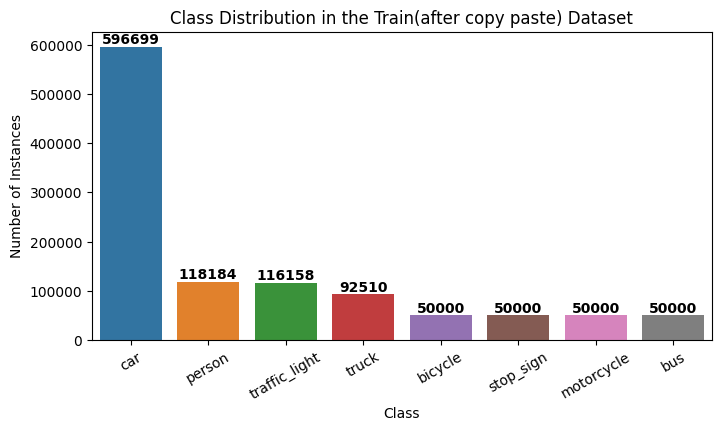

In [ ]:
plot_class_distribution(BALANCED_ANNOTATION_DIR / "balanced_train.json", "Train(after copy paste)") #

#### Applying blurring, brightening, contrast and hue_shift to images.

In [ ]:
#Applying augmentation: Goiung through each folder and rotating the augmentation in a cycle.

# Load JSON
with open(annotation_path, "r") as f:
    train_data = json.load(f)

# Augmentation cycle
AUGMENTATION_CYCLE = [
    "None",
    "blurred",
    "brightened",
    "contrast",
    "hue_shift"
]

# Augmentation functions
def apply_blur(img):
    return cv2.GaussianBlur(img, (11, 11), 0)

def apply_brighten(img, alpha=1.5, beta=30):
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def apply_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    merged = cv2.merge((l2, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

def apply_hue_shift(img, delta=15):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv[:, :, 0] = (hsv[:, :, 0] + delta) % 180
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

AUG_FUNCTIONS = {
    "blurred": apply_blur,
    "brightened": apply_brighten,
    "contrast": apply_contrast,
    "hue_shift": apply_hue_shift
}

# Apply augmentations
counter = 0
for folder in sorted((IMAGE_DIR / "train").iterdir()):
    ring_dir = folder / "ring_front_center"
    if not ring_dir.exists() or not ring_dir.is_dir():
        continue

    for img_file in sorted(ring_dir.glob("*.jpg")):
        # Skip already augmented files
        if any(suffix in img_file.stem for suffix in AUGMENTATION_CYCLE[1:]):
            continue

        aug_index = counter % len(AUGMENTATION_CYCLE)
        aug_type = AUGMENTATION_CYCLE[aug_index]

        if aug_type == "None":
            counter += 1
            continue

        # Load and augment image
        img = cv2.imread(str(img_file))
        if img is None:
            print(f"Skipping unreadable image: {img_file}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        transformed_img = AUG_FUNCTIONS[aug_type](img)

        # Generate new name and path
        stem = img_file.stem
        new_name = f"{stem}_{aug_type}.jpg"
        new_path = img_file.parent / new_name

        # Save new image
        cv2.imwrite(str(new_path), cv2.cvtColor(transformed_img, cv2.COLOR_RGB2BGR))

        # Delete old image
        img_file.unlink()

        # Update image name in JSON (preserving full structure)
        matched = False
        for img_entry in train_data["images"]:
            if Path(img_entry["name"]).name == img_file.name:
                img_entry["name"] = new_name
                matched = True
                break

        if not matched:
            print(f" Could not find JSON entry for: {img_file.name}")

        else:
            print(f" {img_file.name} → {new_name}")

        counter += 1

# Save updated JSON
with open(annotation_path, "w") as f:
    json.dump(train_data, f, indent=4)

print("\n Cyclic augmentations applied. All images renamed and JSON updated.")

Streaming output truncated to the last 5000 lines.
 ring_front_center_315971353192259880.jpg → ring_front_center_315971353192259880_contrast.jpg
 ring_front_center_315971353225559976.jpg → ring_front_center_315971353225559976_hue_shift.jpg
 ring_front_center_315971353292160120.jpg → ring_front_center_315971353292160120_blurred.jpg
 ring_front_center_315971353325460136.jpg → ring_front_center_315971353325460136_brightened.jpg
 ring_front_center_315971353358760264.jpg → ring_front_center_315971353358760264_contrast.jpg
 ring_front_center_315971353392060360.jpg → ring_front_center_315971353392060360_hue_shift.jpg
 ring_front_center_315971353458660504.jpg → ring_front_center_315971353458660504_blurred.jpg
 ring_front_center_315971353491960600.jpg → ring_front_center_315971353491960600_brightened.jpg
 ring_front_center_315971353525260728.jpg → ring_front_center_315971353525260728_contrast.jpg
 ring_front_center_315971353558560744.jpg → ring_front_center_315971353558560744_hue_shift.jpg
 rin

#### Visualizing Augmentations

In [ ]:
def visualize_augmented_image(aug_type="blurred"):
    # Load annotation file
    with open(annotation_path, "r") as f:
        balanced_data = json.load(f)

    # Build sid to folder mapping
    seq_dirs = balanced_data["seq_dirs"]
    sid_to_folder = {
        i: seq_dirs[i].replace("train/", "").replace("/ring_front_center", "")
        for i in range(len(seq_dirs))
    }

    # Build image info
    image_info = {
        img["id"]: {
            "name": img.get("name", img.get("file_name")),
            "video_folder": sid_to_folder.get(img.get("sid"), "unknown"),
            "width": img["width"],
            "height": img["height"]
        }
        for img in balanced_data["images"]
    }

    # Find an image with the given augmentation type
    target_img_entry = next(
        (img for img in balanced_data["images"] if f"_{aug_type}" in img.get("name", "")),
        None
    )

    if not target_img_entry:
        print(f" No image found with augmentation: {aug_type}")
        return

    img_id = target_img_entry["id"]
    img_name = target_img_entry["name"]
    folder = image_info[img_id]["video_folder"]

    # Construct path
    img_path = IMAGE_DIR / "train" / folder / "ring_front_center" / img_name
    if not img_path.exists():
        print(f" Image file not found: {img_path}")
        return

    # Load and convert image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get annotations
    bboxes = [ann for ann in balanced_data["annotations"] if ann["image_id"] == img_id]

    # Plot
    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)

    for bbox in bboxes:
        x, y, w, h = bbox["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, f"Class {bbox['category_id']}", color='white',
                fontsize=9, bbox=dict(facecolor='green', alpha=0.5))

    ax.set_title(f"{aug_type.capitalize()} image with bounding boxes")
    ax.axis("off")
    plt.show()

AUGS = ["flipped", "blurred", "brightened", "contrast", "hue_shift"]
for aug in AUGS:
    print(f"\n Augmentation: {aug}")
    visualize_augmented_image(aug)

In [ ]:
#Saving the augmented dataset for further use
!cp -r /content/balanced_Agroverse "/content/drive/MyDrive/Colab Notebooks/Team 8 Capstone/datasets/"
